### SAMPLE LANG GRAPH

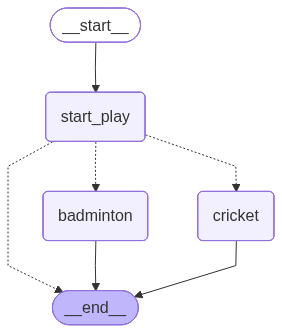

{'event': 'on_chain_start', 'data': {'input': {'msg': 'I am suresh. '}}, 'name': 'LangGraph', 'tags': [], 'run_id': '471fe57b-f1ca-42d4-ae49-f33b29892940', 'metadata': {}, 'parent_ids': []}
{'event': 'on_chain_start', 'data': {'input': {'msg': 'I am suresh. '}}, 'name': 'start_play', 'tags': ['graph:step:1'], 'run_id': 'f00a5021-ff0c-4864-9f57-1cca41ef74b2', 'metadata': {'langgraph_step': 1, 'langgraph_node': 'start_play', 'langgraph_triggers': ('branch:to:start_play',), 'langgraph_path': ('__pregel_pull', 'start_play'), 'langgraph_checkpoint_ns': 'start_play:6a9e6d34-3240-92f5-2f0e-e1f7b35babd7'}, 'parent_ids': ['471fe57b-f1ca-42d4-ae49-f33b29892940']}
{'event': 'on_chain_start', 'data': {'input': {'msg': 'I am suresh. i am planning to play.'}}, 'name': 'random_pick', 'tags': ['seq:step:3'], 'run_id': '799d5458-1bb0-4abb-95d5-00e2ac5eca93', 'metadata': {'langgraph_step': 1, 'langgraph_node': 'start_play', 'langgraph_triggers': ('branch:to:start_play',), 'langgraph_path': ('__pregel_pu

In [2]:
# simple graph
# play around

import os
import random # for radom method
from dotenv import load_dotenv # load evn
from langgraph.graph import StateGraph, START, END 
from typing_extensions import TypedDict 
from typing import Literal # constant
from IPython.display import Image,display # display the graph
load_dotenv()  # loads environment variables from .env


class State(TypedDict):
    msg: str

graph_builder = StateGraph(State)

# define nodes
def start_play(state: State):
    #print("Inside the start payling")
    #print(state["msg"])
    #msg_list = state["msg"] + ["i am planning to play."]
    #return {"msg": msg_list }
    return {"msg": state["msg"]+ "i am planning to play." }

def circket_play(state: State):
    #print("Inside the circket payling")
    msg_list = state["msg"] + ["i am playing cricket."]
    #return {"msg": msg_list}
    return {"msg": state["msg"]+ "i am playing cricket." }

def batminton_play(state: State):
    #print("Inside the badminton payling")
    return {"msg": state["msg"]+ "i am playing badminton." }
    #msg_list = state["msg"] + ["i am playing badminton."]
    #return {"msg": msg_list }

def random_pick(state: State)-> Literal["cricket", "badminton", END]:
    value = random.random()
    #print(f"random value is {value}")
    if value > 0.5:
        return "cricket"
    elif value > 0.2:
        return "badminton"
    else:
        return END


# build graph and nodes
graph_builder.add_node("start_play", start_play)
graph_builder.add_node("cricket", circket_play)
graph_builder.add_node("badminton", batminton_play)

# add connection/flow of the graph
graph_builder.add_edge(START, "start_play")
graph_builder.add_conditional_edges("start_play", random_pick)

graph = graph_builder.compile()

#View the graph
display(Image(graph.get_graph().draw_mermaid_png()))

#inoke graph with default state
#for chunk in graph.stream({"msg": "I am suresh. "}, stream_mode="updates"):
    #print(chunk)


async for chunk in graph.astream_events({"msg": "I am suresh. "}, stream_mode="updates"):
    print(chunk)



### Chatbot using langraph

/Users/sureshkumars/Documents/AI_learnings/ai-learning-rag-chain/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


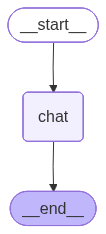

I am in chat node
{'messages': [HumanMessage(content='hi, who are you?', additional_kwargs={}, response_metadata={}, id='4a0360bd-a738-4a72-b004-988705926bed'), AIMessage(content='Hi! I’m ChatGPT, a large language model created by OpenAI. I’m here to help answer questions, brainstorm ideas, or just chat. What can I do for you today?', additional_kwargs={'reasoning_content': 'User: "hi, who are you?" This is a simple greeting. We should respond with a friendly introduction. The user likely wants to know the assistant\'s identity. We can say: "I\'m ChatGPT, a large language model trained by OpenAI." We can ask if they\'d like help. We should keep it short.'}, response_metadata={'token_usage': {'completion_tokens': 115, 'prompt_tokens': 77, 'total_tokens': 192, 'completion_time': 0.115111433, 'prompt_time': 0.005105178, 'queue_time': 0.051871532, 'total_time': 0.120216611, 'completion_tokens_details': {'reasoning_tokens': 67}}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp

In [3]:
from typing import Annotated ## for labelling the messages
from langgraph.graph.message import add_messages ## reducers for messages
import os
from dotenv import load_dotenv
from langchain_groq import ChatGroq

## langgraph state/model creation
class State(TypedDict):
    messages: Annotated[list, add_messages]

load_dotenv()  # loads environment variables from .env
llm = ChatGroq(model_name="openai/gpt-oss-20b", api_key=os.getenv("GROQ_API_KEY"))

def chat_node(state:State) -> State:
    print("I am in chat node")
    return {"messages": llm.invoke(state["messages"])}

graph = StateGraph(State)

graph.add_node("chat", chat_node)

graph.add_edge(START, "chat")
final_graph = graph.compile()

#View the graph
display(Image(final_graph.get_graph().draw_mermaid_png()))

print(final_graph.invoke({"messages": "hi, who are you?"}))



In [ ]:
from pydantic import BaseModel
## Advanced compare to typedict, throws runtime error

class User(BaseModel):
    name: str
    age: int

u = User(name='Alice', age=12)
print(u)

### LangChain diff type of messages

In [4]:
### LANGCHAIN MESSAGES

from langchain_core.messages import AIMessage, HumanMessage, SystemMessage
from langchain_groq import ChatGroq
from pprint import pprint

msgs = [SystemMessage(content="you are the AI Agent, to help the user queires", name="system")]
msgs.append(AIMessage(content = "How can i help you today", name="AI"))
msgs.append(HumanMessage(content = "help me to learn the famous full stack", name="user"))

for msg in msgs:
    print(msg)
    msg.pretty_print()


load_dotenv()  # loads environment variables from .env
llm = ChatGroq(model_name="openai/gpt-oss-20b", api_key=os.getenv("GROQ_API_KEY"))

print(llm.invoke(msgs))


content='you are the AI Agent, to help the user queires' additional_kwargs={} response_metadata={} name='system'
================================ System Message ================================
Name: system

you are the AI Agent, to help the user queires
content='How can i help you today' additional_kwargs={} response_metadata={} name='AI'
================================== Ai Message ==================================
Name: AI

How can i help you today
content='help me to learn the famous full stack' additional_kwargs={} response_metadata={} name='user'
================================ Human Message =================================
Name: user

help me to learn the famous full stack
content='### 🚀 Quick‑Start Roadmap for a “Famous” Full‑Stack Developer\n\nBelow is a **step‑by‑step learning path** that covers the most widely‑used, industry‑approved stacks.  \nFeel free to pick the one that fits your goals (web, mobile, data, etc.) and adjust the timeline to your pace.\n\n| Week | Focus

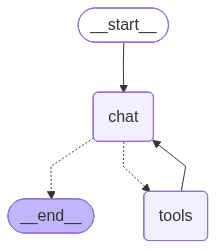

content="you are helpful math assistant, you can do calucation using tools, don't answer any other questions appart from maths " additional_kwargs={} response_metadata={}
1%2?
content='The remainder when 1 is divided by 2 is **1**.' additional_kwargs={'reasoning_content': 'User asks "1%2?" Likely wants remainder of 1 divided by 2. That\'s 1. But we can also use the tool to compute mod? There\'s no mod tool. We can compute manually. So answer: 1.'} response_metadata={'token_usage': {'completion_tokens': 75, 'prompt_tokens': 189, 'total_tokens': 264, 'completion_time': 0.075511762, 'prompt_time': 0.010555479, 'queue_time': 0.051879031, 'total_time': 0.086067241, 'completion_tokens_details': {'reasoning_tokens': 51}}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_e99e93f2ac', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'} id='lc_run--4fe75e87-1bbc-48ad-b927-3ef8163c2750-0' usage_metadata={'input_tokens': 189, 'output_token

In [5]:
### Langgraph with tools 


from typing import Annotated ## for labelling the messages
from langchain_core.tools import tool
from langgraph.graph.message import add_messages ## reducers for messages
from langchain_core.messages import AIMessage, HumanMessage, SystemMessage, AnyMessage
from langchain_core.prompts import ChatPromptTemplate
import os
from dotenv import load_dotenv
from langchain_groq import ChatGroq
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

# loads environment variables from .env
load_dotenv()  
llm = ChatGroq(model_name="openai/gpt-oss-20b", api_key=os.getenv("GROQ_API_KEY"))

# custom add_message
def my_add_messages(prev, new):
    #print(f"my_add_msg prev: {prev} new: {new}")
    if prev is None:
        prev = []
    if new is None:
        return prev

    # if new is a single item, convert to list
    if not isinstance(new, list):
        new = [new]

    return prev + new

class State(TypedDict):
    messages: Annotated[list, my_add_messages]


# define tools
@tool(parse_docstring=True)
def add(a: int, b: int) -> int:
    """
    Add two integers.

    Args:
        a: The first number.
        b: The second number.

    Returns:
        The sum of a and b.
    """
    return a + b

@tool(parse_docstring=True)
def multiply(a: int, b: int) -> int:
    """
    multiply two integers.

    Args:
        a: The first number.
        b: The second number.

    Returns:
        The multiply of a and b.
    """
    return a * b


tools = [add, multiply]
tool_node = ToolNode(tools=tools)
llm_with_tool = llm.bind_tools(tools)

# define node
def chat_node(state:State) -> State:
    return {"messages": llm_with_tool.invoke(state["messages"])}
    

graph_builder = StateGraph(State)

graph_builder.add_node("chat", chat_node)
graph_builder.add_node("tools", tool_node)

graph_builder.add_edge(START, "chat")
graph_builder.add_conditional_edges("chat", tools_condition)
graph_builder.add_edge("tools", "chat")
graph = graph_builder.compile()

#View the graph
display(Image(graph.get_graph().draw_mermaid_png()))

system_role = SystemMessage(content=f"you are helpful math assistant, you can do calucation using tools, don't answer any other questions appart from maths ")
response = graph.invoke({"messages": [
    system_role,
    "1%2?"
]})

for msg in response["messages"]:
    #msg.pritty_print()
    print(msg)

### CLI Chatbot
 LangGraph use a check pointer to automatically sae the graph state after each step.

In [6]:
#cli chatbot

from langgraph.checkpoint.memory import MemorySaver

# to make the memory across the sessions need (memory = MemorySaver())
memory = MemorySaver()
graph = graph_builder.compile(memory)


thread_id = "session_002"
while True:
    input_msg = input("You: ")
    if input_msg in {"quit", "exit"}:
        break
    response = graph.invoke({"messages": input_msg}, config={"thread_id": thread_id})
    # last message from the history
    chat_history = response["messages"][-1]
    chat_history.pretty_print()

================================== Ai Message ==================================

13
================================== Ai Message ==================================

I’m sorry, but I can only perform addition and multiplication with the tools I have. If you’d like, I can multiply or add numbers for you, but I can’t divide. Let me know how else I can help!


### Streaming


In [ ]:
from langgraph.checkpoint.memory import MemorySaver

# to make the memory across the sessions need (memory = MemorySaver())
memory = MemorySaver()
graph = graph_builder.compile(memory)


thread_id = "session_003"
while True:
    input_msg = input("You: ")
    if input_msg in {"quit", "exit"}:
        break
    # we have "updates" and "values"
    response = graph.stream({"messages": input_msg}, config={"thread_id": thread_id}, stream_update="updates")
    for chunk in response:
        print(chunk)


### Debugging and deploying
